In [53]:
import argparse
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random 
import networkx as nx
import tensorflow as tf

from tensorflow import keras
from tqdm import tqdm
from pathlib import Path

from tensorflow.keras.utils import pad_sequences

from astroOracle.LSST_Source import LSST_Source
from astroOracle.dataloader import LSSTSourceDataSet, load, get_augmented_data, get_static_features, ts_length, get_ts_upto_days_since_trigger, ts_flag_value, static_flag_value, augment_ts_length_to_days_since_trigger, get_ts_upto_days_since_trigger_deg, augment_ts_length_to_days_since_trigger_deg
from astroOracle.loss import WHXE_Loss
from astroOracle.taxonomy import get_taxonomy_tree, source_node_label
from astroOracle.vizualizations import make_gif, plot_reliability_diagram, plot_data_set_composition, plot_day_vs_class_score, plot_lc, make_z_plots
from astroOracle.interpret_results import get_conditional_probabilites, save_all_cf_and_rocs, save_leaf_cf_and_rocs, save_all_phase_vs_accuracy_plot
from astroOracle.train_RNN import default_batch_size

default_seed = 40
default_test_dir = Path("../processed/test")
default_max_class_count = 1
days = 2 ** np.array(range(11))

In [78]:
def plot_lc(table, class_name, ax1, file_name=None):

    def get_pb_color(wavelength):

        all_wavelengths = list(LSST_Source.pb_wavelengths.values())
        all_wavelengths.sort()
        idx = all_wavelengths.index(wavelength)

        return f"C{idx}"

    def get_legend_patches():

        patches = []

        all_wavelengths = list(LSST_Source.pb_wavelengths.values())
        all_wavelengths.sort()

        for passband in LSST_Source.pb_wavelengths:

            wavelength = LSST_Source.pb_wavelengths[passband]
            idx = all_wavelengths.index(wavelength)
            patch = mpatches.Patch(color=f"C{idx}", label=passband)
            patches.append(patch)

        return patches

    times = table['scaled_time_since_first_obs'].to_numpy()
    first_detection_idx = np.where(table['detection_flag'].to_numpy() == 1)[0][0]
    first_detection_t = times[first_detection_idx]
    days_since_trigger = (times - first_detection_t) * 100

    flux = table['scaled_FLUXCAL'].to_numpy() * LSST_Source.flux_scaling_const
    flux_err = table['scaled_FLUXCALERR'].to_numpy() * LSST_Source.flux_scaling_const
    detection_mask = table['detection_flag'].to_numpy() == 1
    non_detection_mask = table['detection_flag'].to_numpy() == 0
    colors = np.array([get_pb_color(w) for w in table['band_label'].to_numpy()])

    # Plot the detections
    for c in np.unique(colors):

        color_mask = colors == c
        combined_mask = color_mask & detection_mask
        ax1.errorbar(x=days_since_trigger[combined_mask], y=flux[combined_mask], yerr=flux_err[combined_mask], color=c, fmt="*", label=c)


    # Plot the non detections
    ax1.scatter(days_since_trigger[non_detection_mask], flux[non_detection_mask], color=colors[non_detection_mask], marker="x", alpha=0.5)

    #ax1.set_xlim(-20, 200)
    ax1.axvspan(-20, 0, color='gray', alpha=0.15)

    ax1.set_xlabel('Days from first detection')
    ax1.set_ylabel('Calibrated Flux')
    ax1.set_title(f"True class: {class_name}")


    #ax1.legend(handles=get_legend_patches())

    
    #plot_lc_legend(filename=f"lcs/legend.pdf")


In [79]:
def run_day_wise_analysis(tree, X_ts, X_static, Y, astrophysical_classes):
    


    def get_ts_upto_days_since_trigger_deg(X_ts, days, add_padding=True):

        augmented_list = []
    
        # Loop through all the data
        for ind in tqdm(range(len(X_ts)), desc ="TS Augmentation: ", disable=True):
    
            times = X_ts[ind]['scaled_time_since_first_obs'].to_numpy()
    
            # Get the idx of the first detection
            first_detection_idx = np.where(X_ts[ind]['detection_flag'].to_numpy() == 1)[0][0]
            first_detection_t = times[first_detection_idx]
    
            if len(np.where((times - first_detection_t) * 100 <= days)[0]) == 0:
                augmented_list.append(np.zeros_like(X_ts[ind].to_numpy()))
            else:
                # Get the index of the the last observation between the mjd(first detection) and  mjd(first detection)
                last_observation_idx = np.where((times - first_detection_t) * 100 <= days)[0][-1]
                
                # Slice the data appropriately, Keep the first new_length number of observations and all columns
                augmented_list.append(X_ts[ind].to_numpy()[first_detection_idx:(last_observation_idx + 1), :][::2]) # the [::2] will skip every other obs
    
        # Optionally - Pad for TF masking layer
        if add_padding:
            augmented_list = pad_sequences(augmented_list, maxlen=ts_length,  dtype='float32', padding='post', value=ts_flag_value)
    
        return augmented_list
    
    all_predictions = []
    all_trues = []


    for d in days:

        print(f'Running inference for trigger + {d} days...')

        x1 = get_ts_upto_days_since_trigger_deg(X_ts, d, add_padding=False)

        # Create one figure with 5×4 axes
        fig, axs = plt.subplots(5, 4, figsize=(16, 12))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)
        
        # axs is a 2D array of Axes → flatten to iterate
        axs = axs.flatten()

        for k, a, ax in zip(x1, astrophysical_classes, axs[:-1]):

            #print(k)
            table = pd.DataFrame(k, columns=['scaled_time_since_first_obs', 'detection_flag', 'scaled_FLUXCAL', 'scaled_FLUXCALERR', 'band_label'])
            plot_lc(table, a, ax)
        plt.show()


In [56]:
max_class_count=default_max_class_count
test_dir=default_test_dir
random.seed(default_seed)

# This step takes a while because it has load from disc to memory...
print("Loading testing data from disc...")
X_ts = load(f"{test_dir}/x_ts.pkl")
X_static = load(f"{test_dir}/x_static.pkl")
Y = load(f"{test_dir}/y.pkl")
astrophysical_classes = load(f"{test_dir}/a_labels.pkl")

z_arr = [X_static[i]['REDSHIFT_HELIO'] for i in range(len(X_static))]

#make_z_plots(astrophysical_classes, z_arr, X_static, model_dir)

a, b = np.unique(astrophysical_classes, return_counts=True)
print(f"Total sample count = {np.sum(b)}")
print(pd.DataFrame(data = {'Class': a, 'Count': b}))

for i in tqdm(range(len(X_static))):        
    X_static[i] = get_static_features(X_static[i])

X_ts_balanced = []
X_static_balanced = []
Y_balanced = []
astrophysical_classes_balanced = []

# Fix random seed while generating LCs for figure 19
#random.seed(42)

for c in np.unique(astrophysical_classes):

    idx = list(np.where(np.array(astrophysical_classes) == c)[0])
    
    if len(idx) > max_class_count:
        idx = random.sample(idx, max_class_count)

    X_ts_balanced += [X_ts[i] for i in idx]
    X_static_balanced += [X_static[i] for i in idx]
    Y_balanced += [Y[i] for i in idx]
    astrophysical_classes_balanced += [astrophysical_classes[i] for i in idx]

# Print summary of the data set used for testing
a, b = np.unique(astrophysical_classes_balanced, return_counts=True)
data_summary = pd.DataFrame(data = {'Class': a, 'Count': b})
print(data_summary)

del X_ts, X_static, Y, astrophysical_classes

tree = get_taxonomy_tree()





Loading testing data from disc...
Total sample count = 463528
            Class   Count
0             AGN   32681
1            CART    3517
2         Cepheid    5901
3     Delta Scuti    8849
4     Dwarf Novae    3439
5              EB   28480
6            ILOT    3197
7              KN    1896
8   M-dwarf Flare     796
9            PISN   27250
10       RR Lyrae    6014
11           SLSN   28322
12        SNI91bg   12272
13           SNII  129230
14           SNIa   51745
15          SNIax   12012
16         SNIb/c   72105
17            TDE   28285
18          uLens    7537


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 463528/463528 [00:01<00:00, 241053.07it/s]


            Class  Count
0             AGN      1
1            CART      1
2         Cepheid      1
3     Delta Scuti      1
4     Dwarf Novae      1
5              EB      1
6            ILOT      1
7              KN      1
8   M-dwarf Flare      1
9            PISN      1
10       RR Lyrae      1
11           SLSN      1
12        SNI91bg      1
13           SNII      1
14           SNIa      1
15          SNIax      1
16         SNIb/c      1
17            TDE      1
18          uLens      1


Running inference for trigger + 1 days...


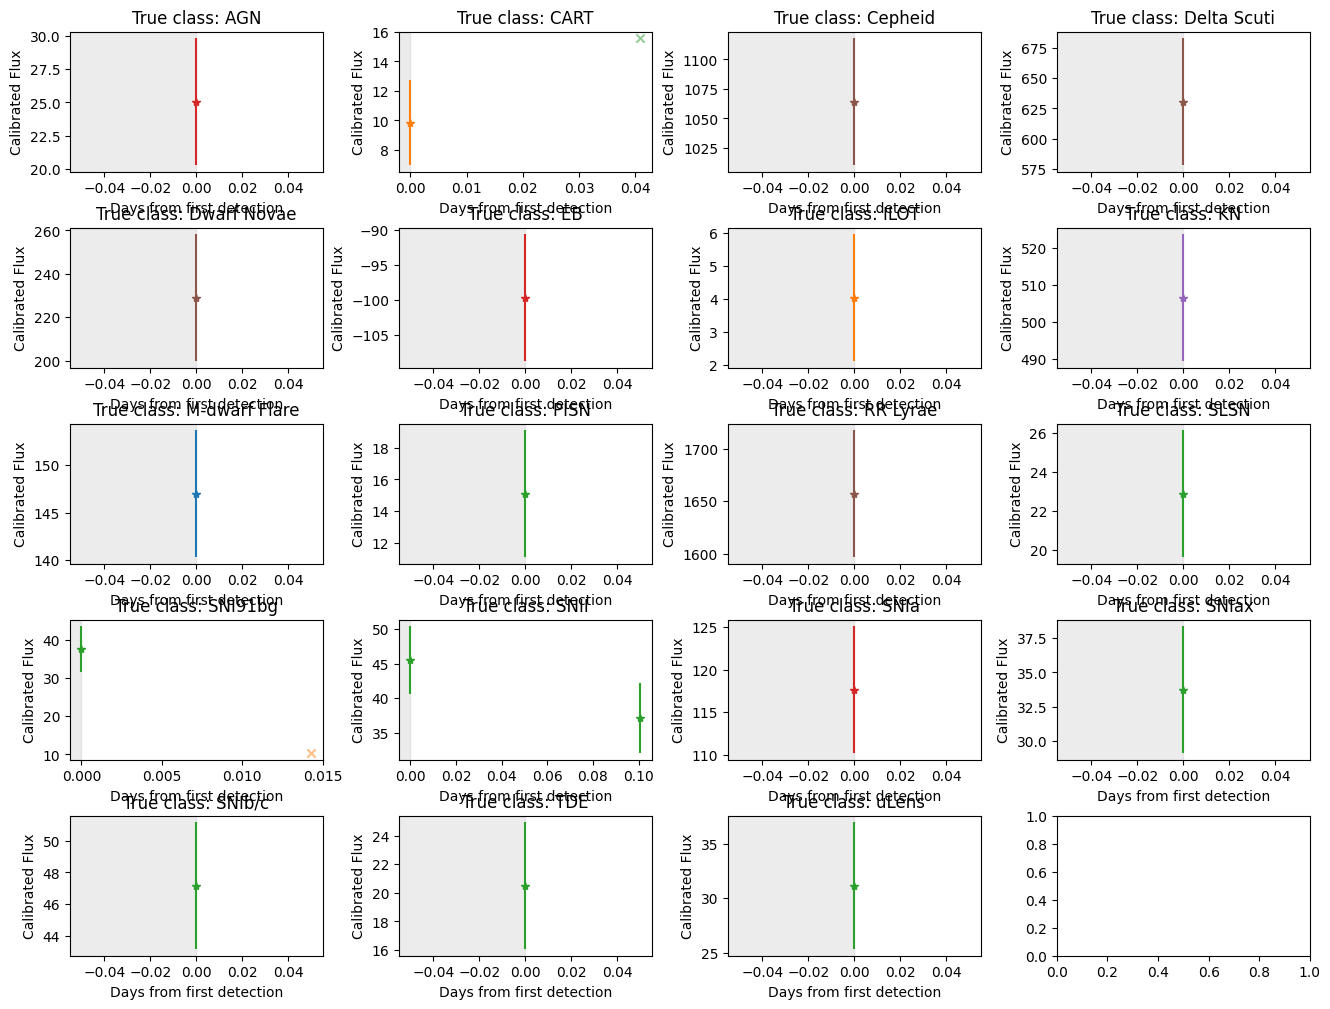

Running inference for trigger + 2 days...


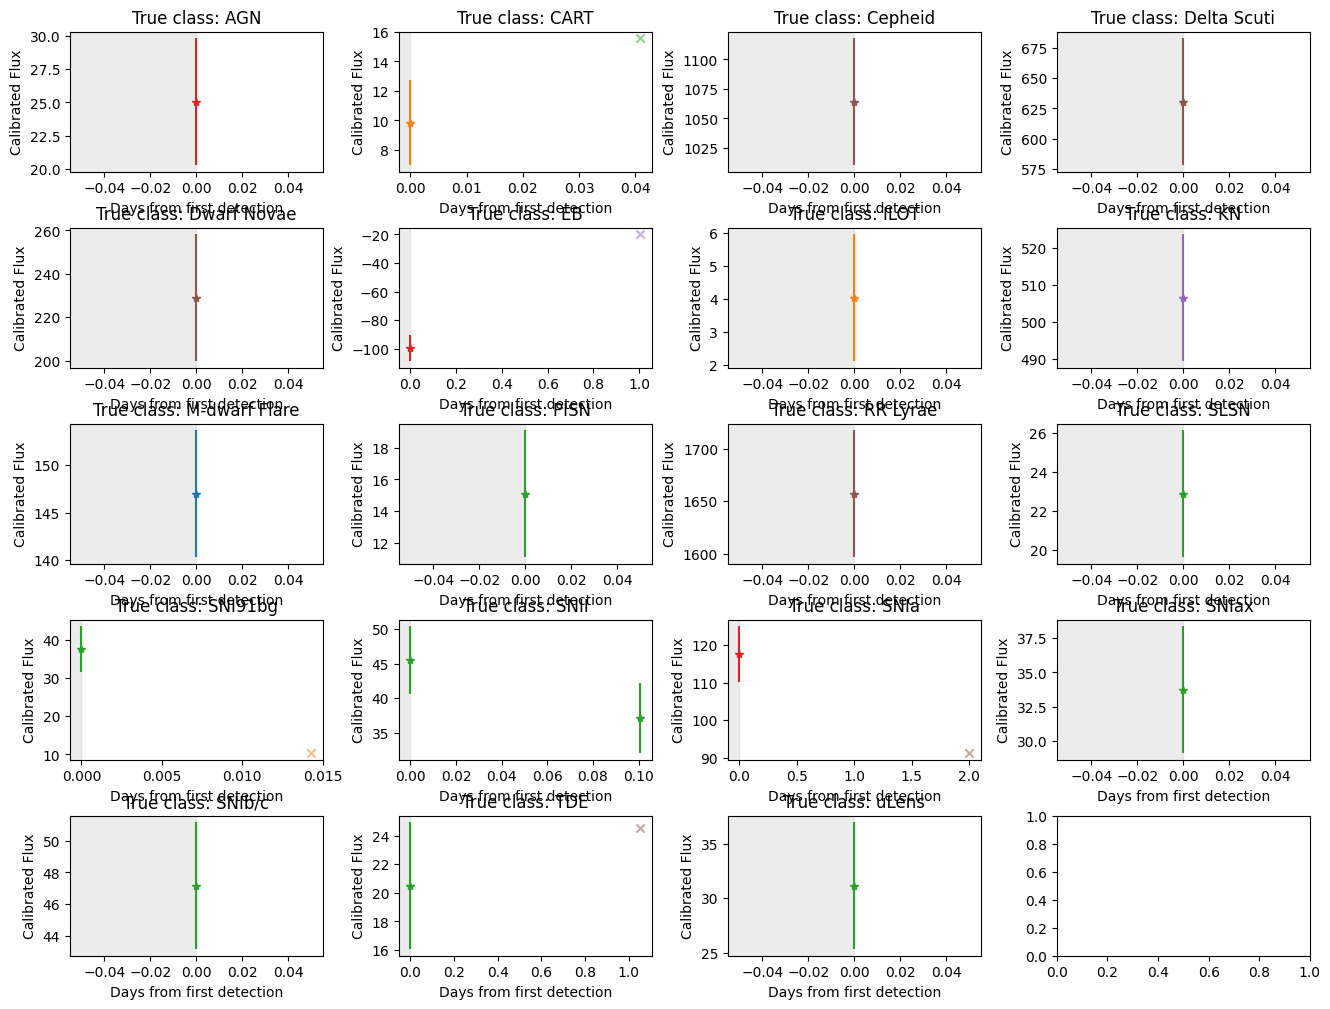

Running inference for trigger + 4 days...


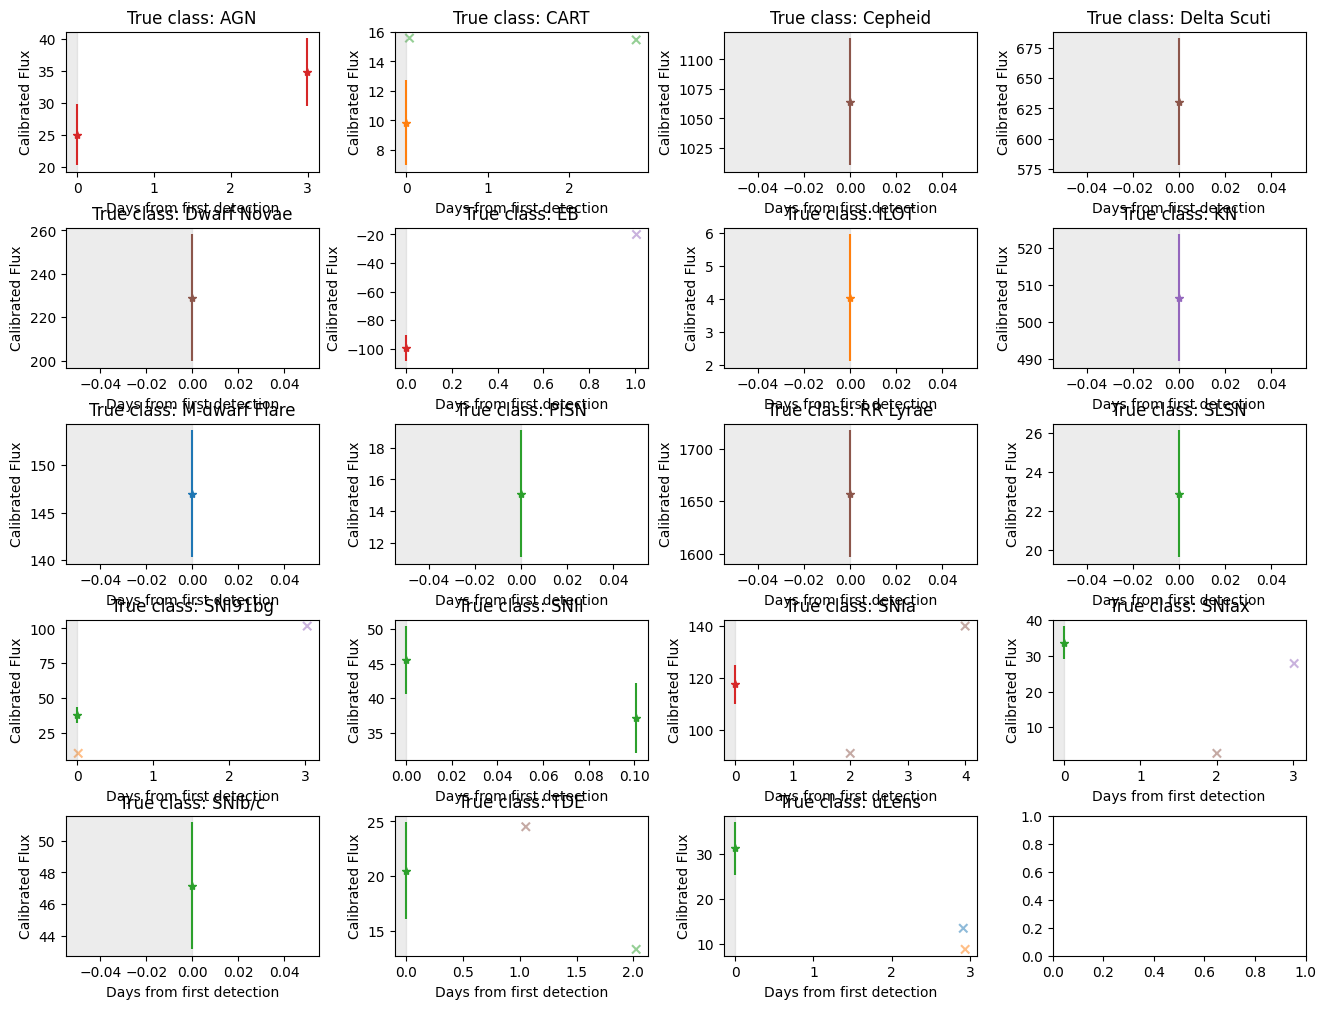

Running inference for trigger + 8 days...


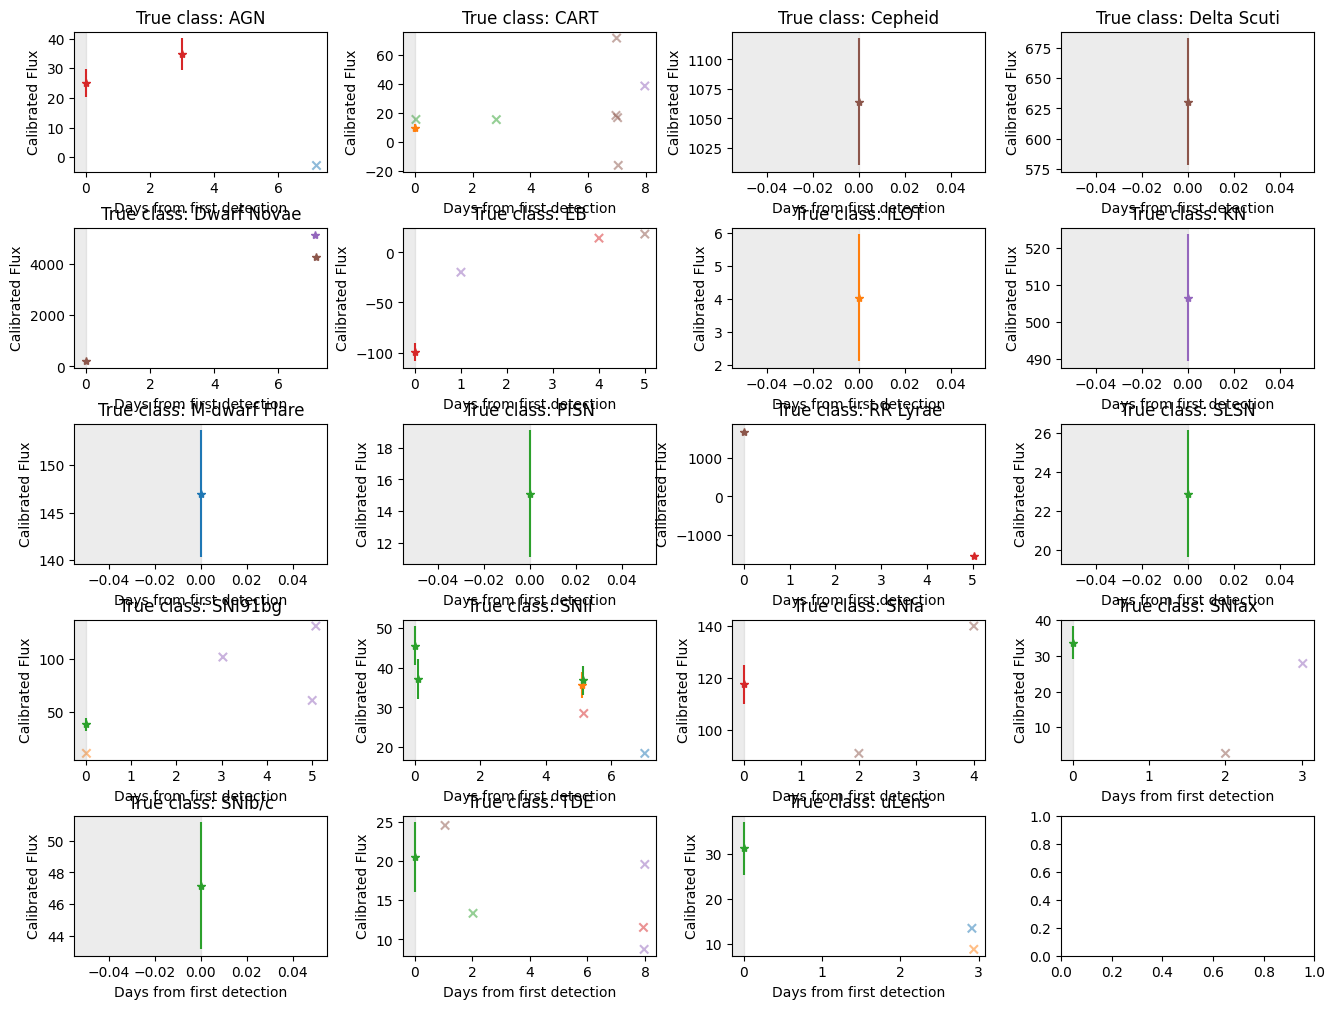

Running inference for trigger + 16 days...


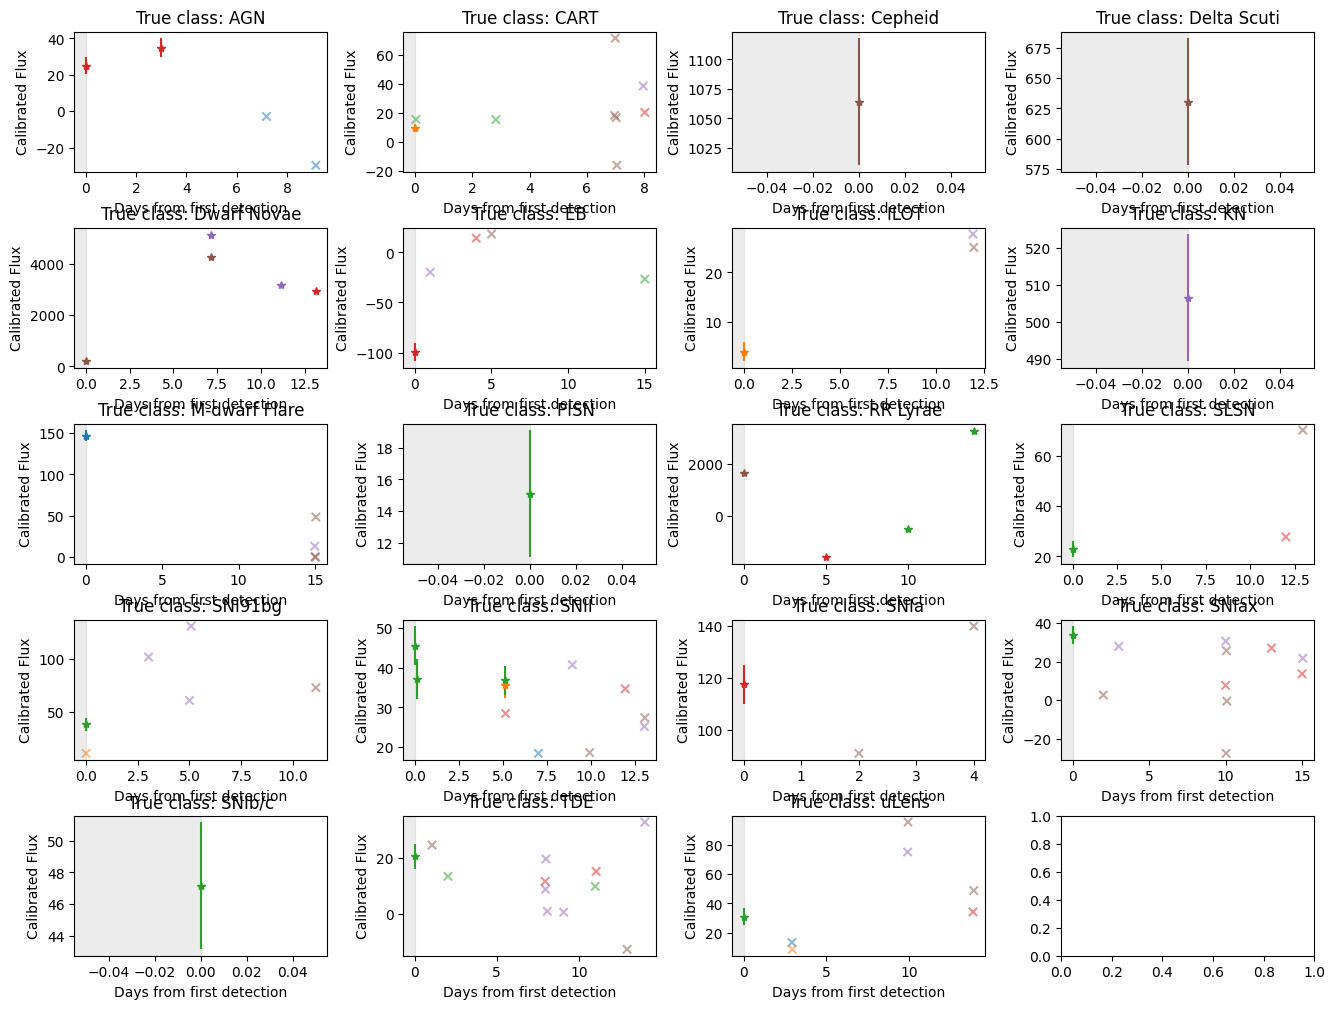

Running inference for trigger + 32 days...


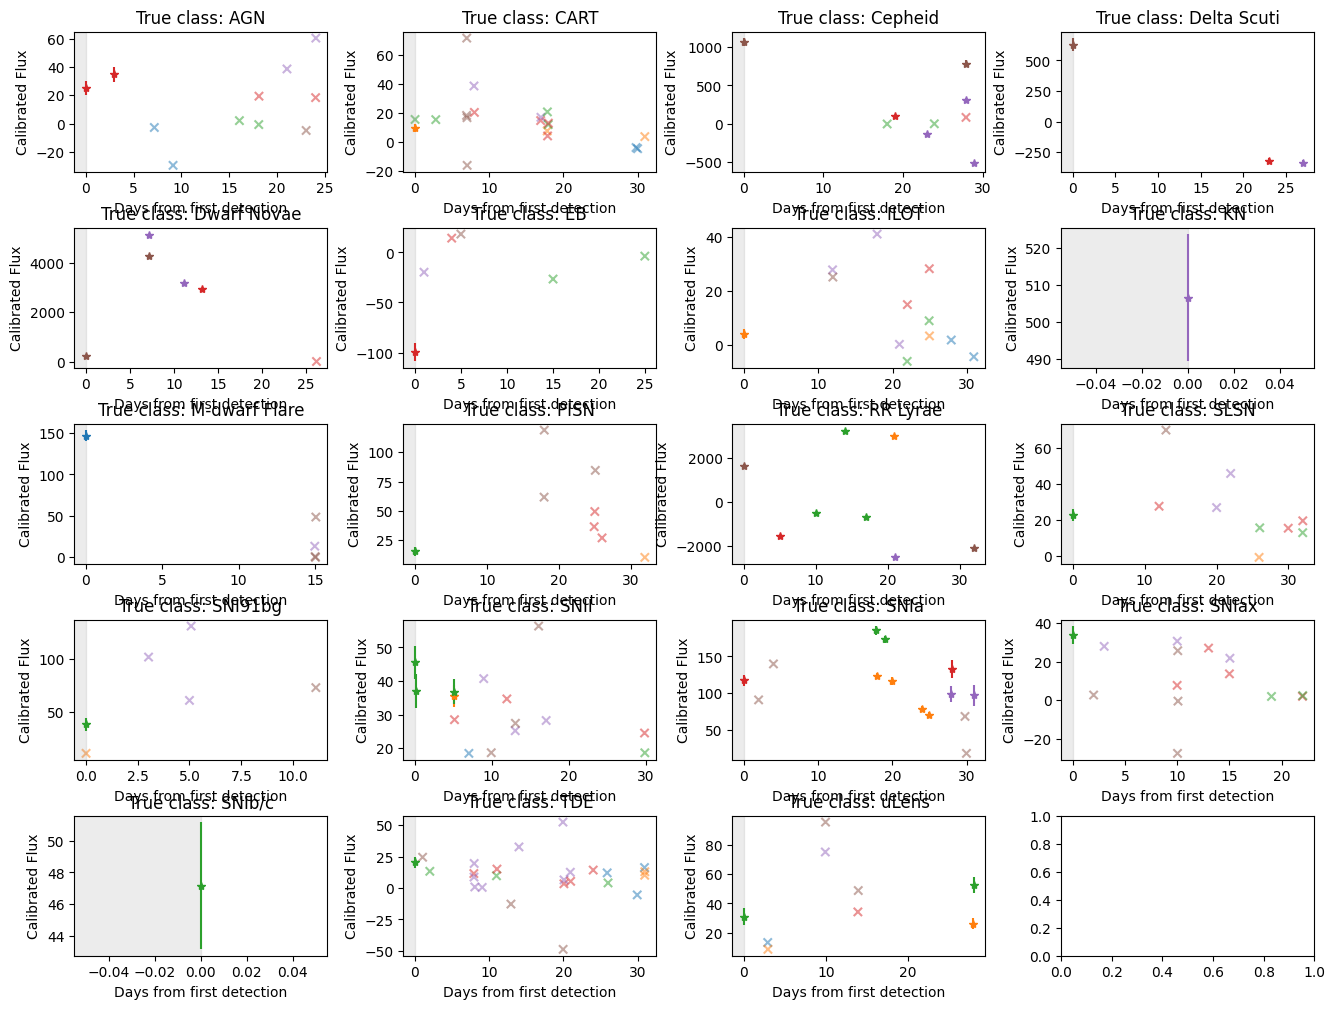

Running inference for trigger + 64 days...


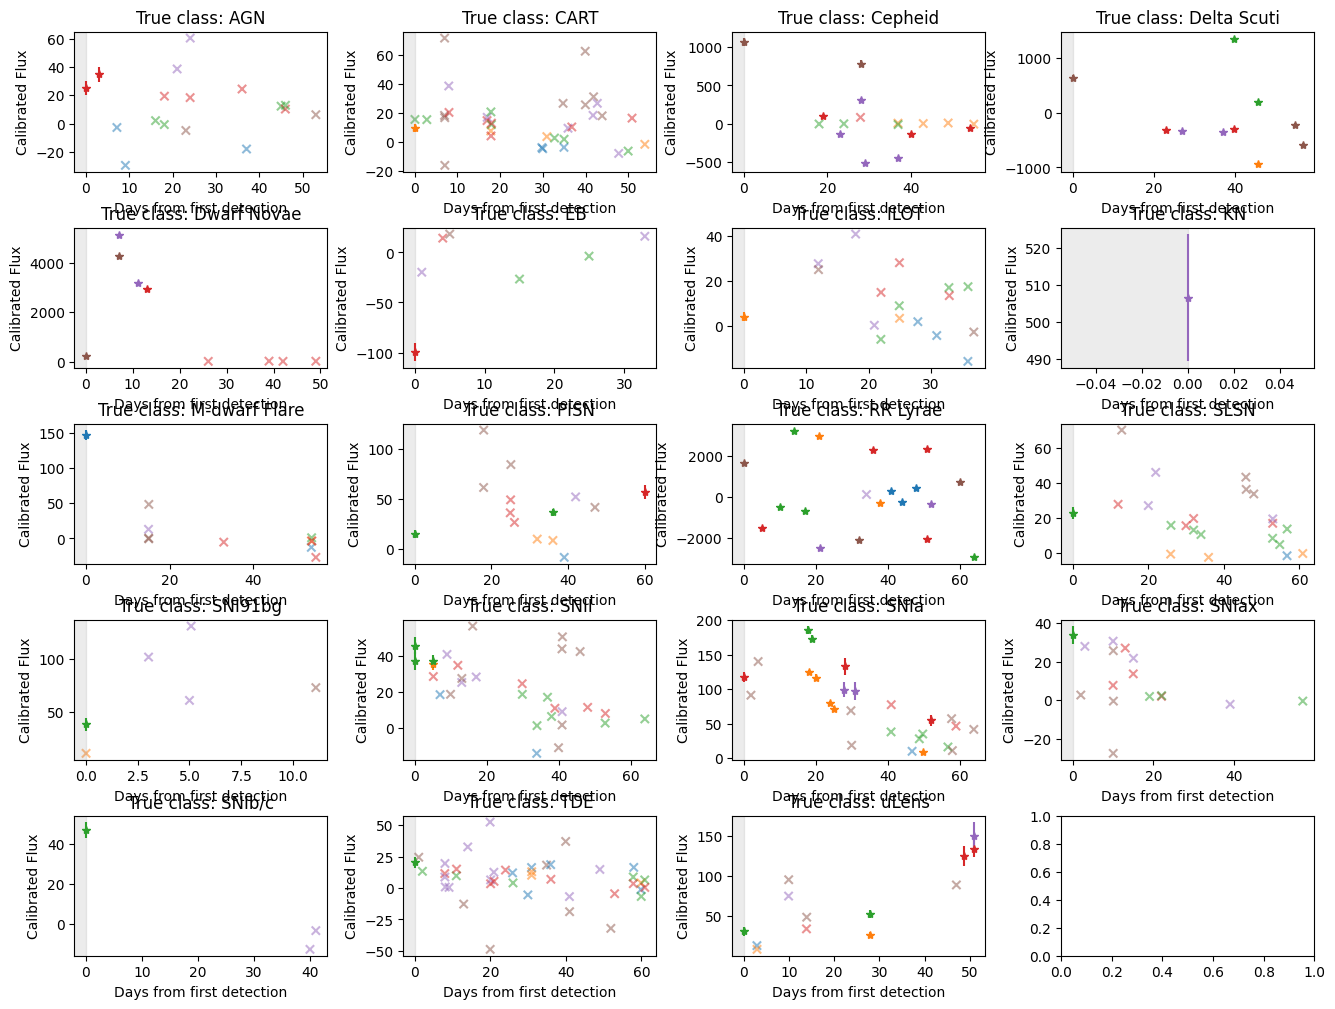

Running inference for trigger + 128 days...


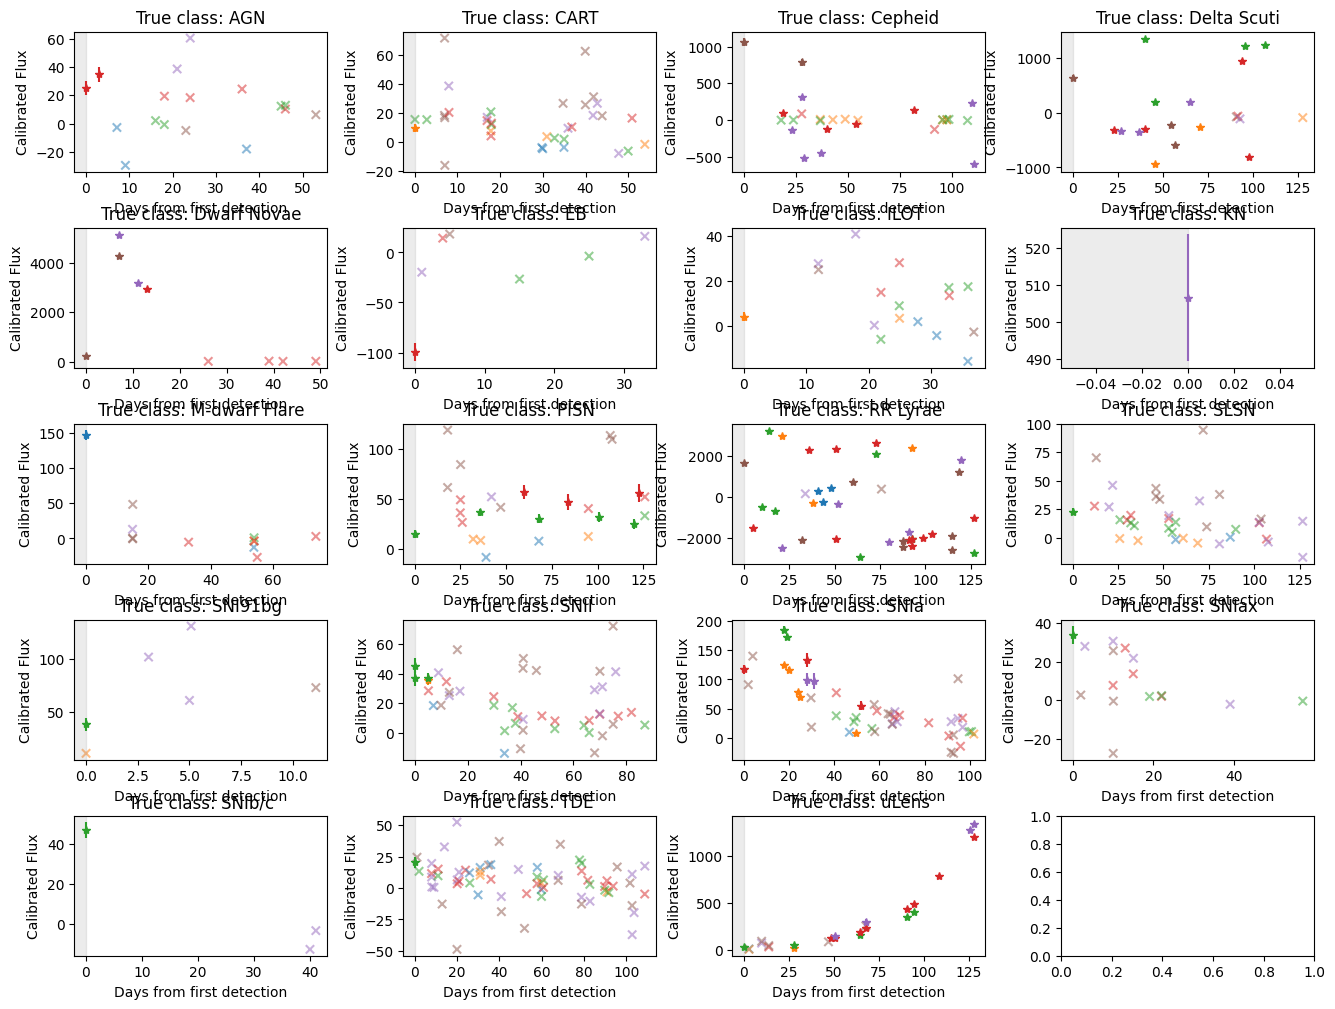

Running inference for trigger + 256 days...


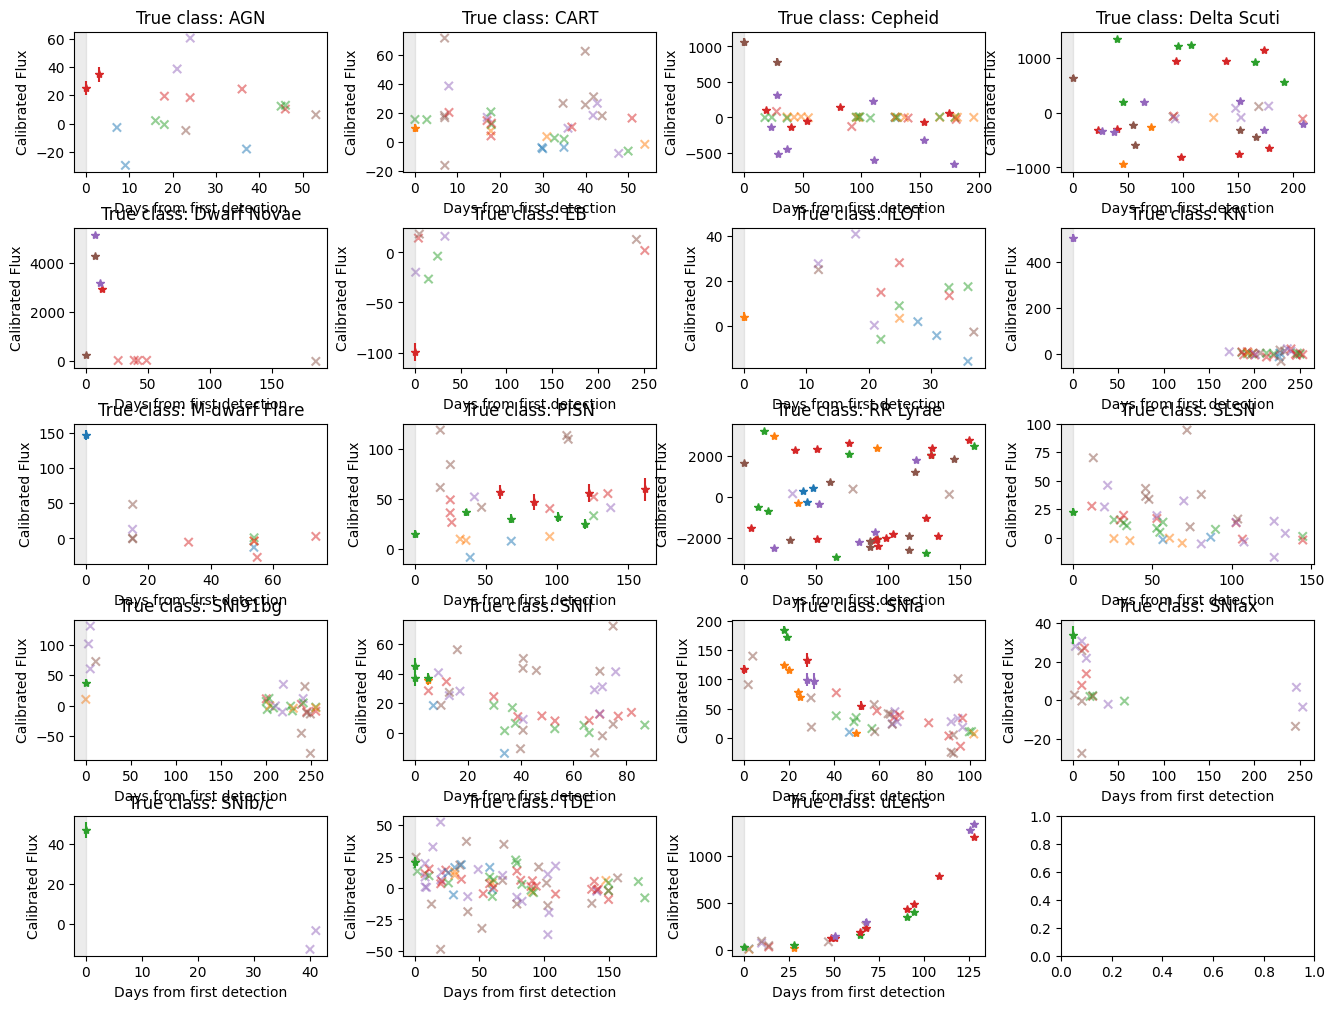

Running inference for trigger + 512 days...


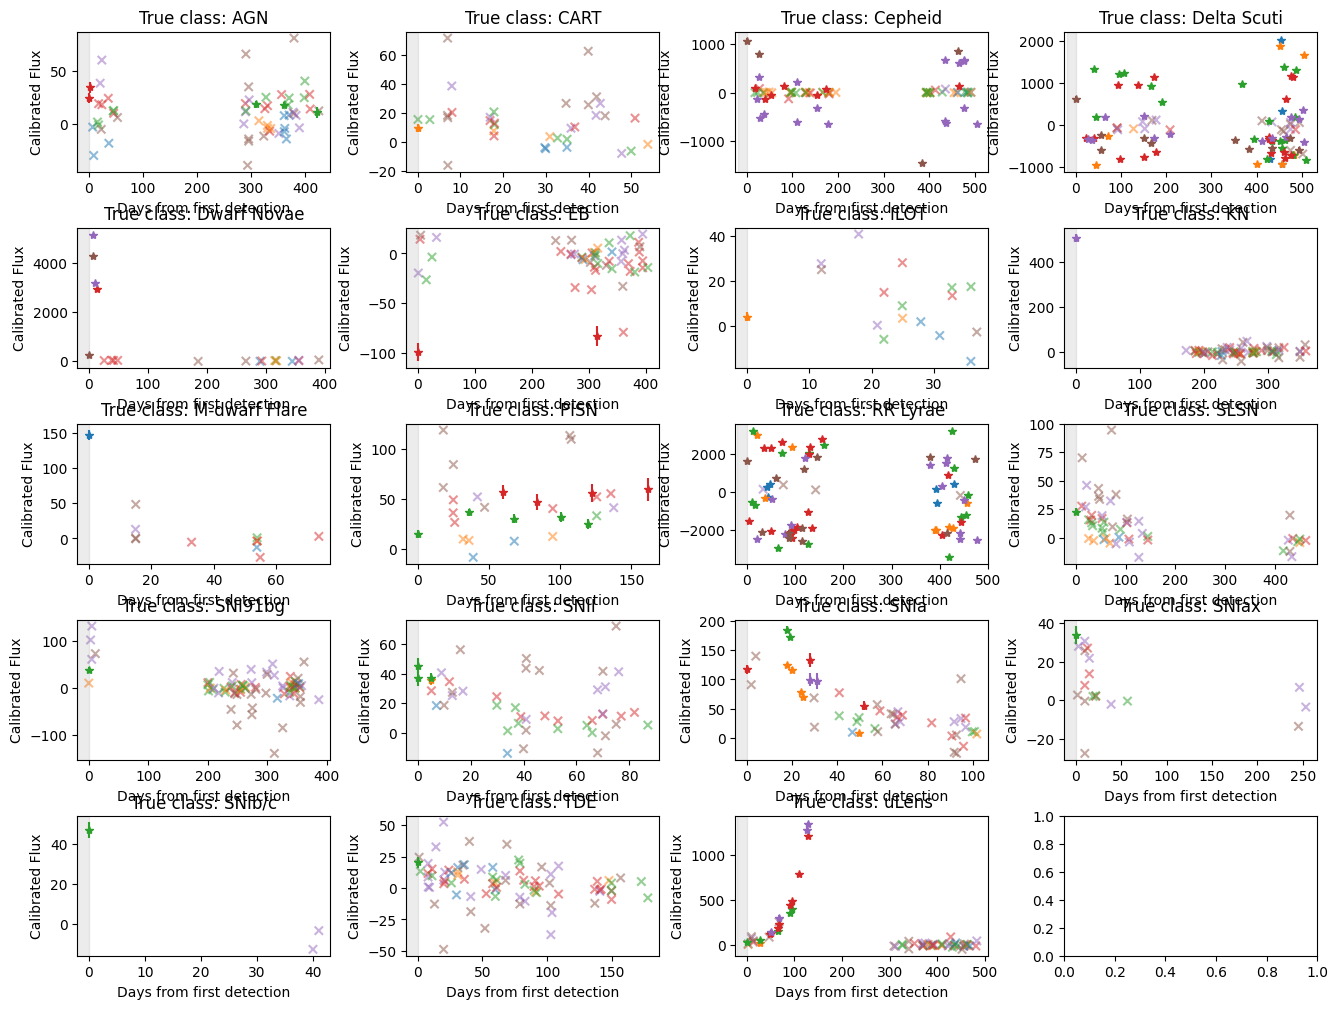

Running inference for trigger + 1024 days...


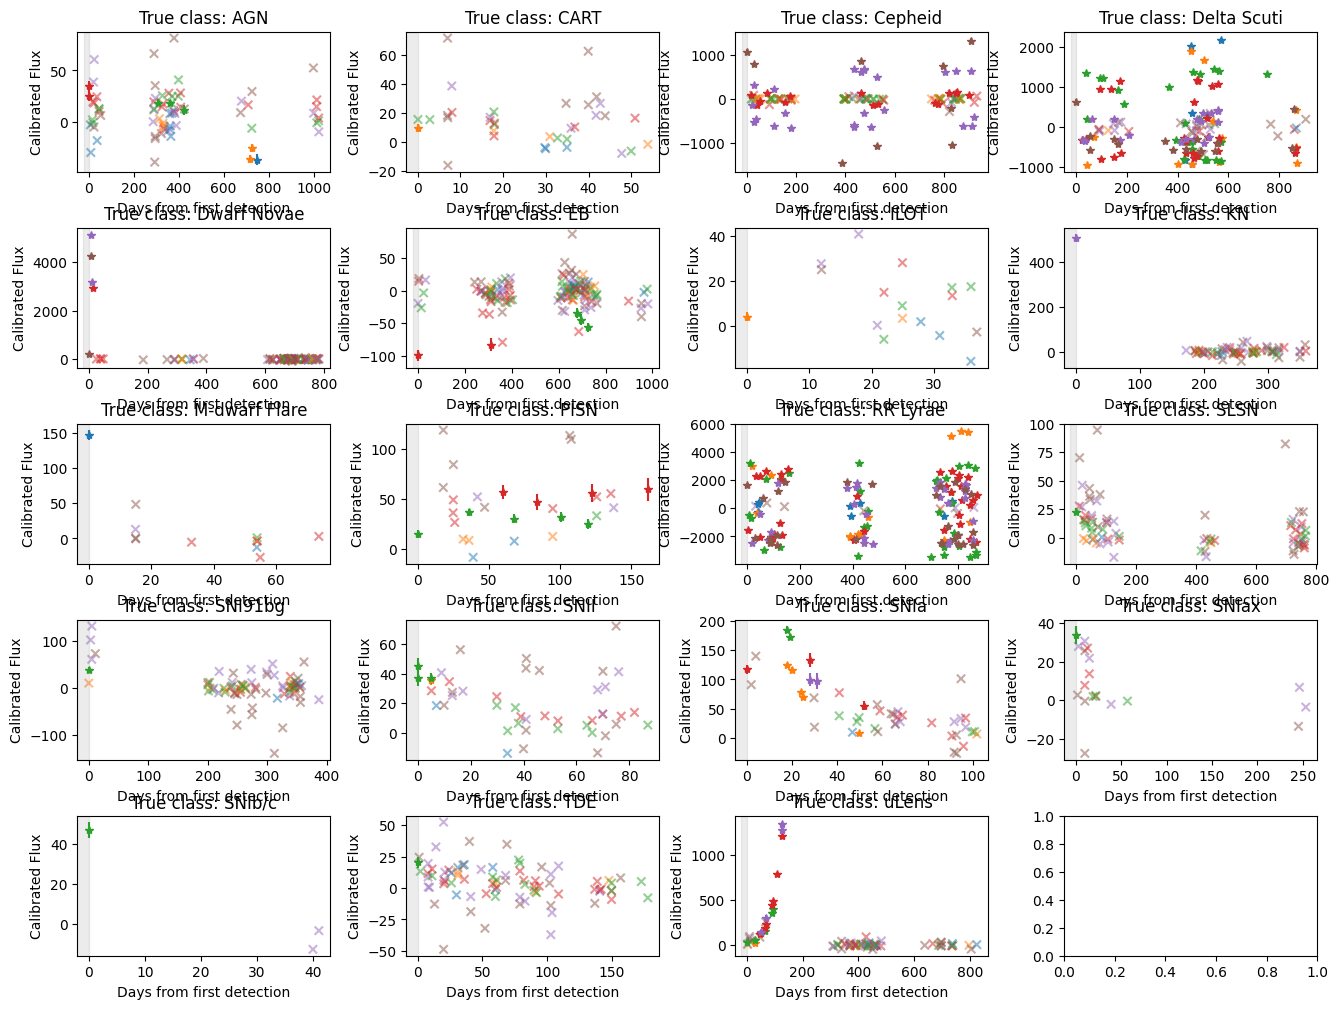

In [80]:
run_day_wise_analysis(tree, X_ts_balanced, X_static_balanced, Y_balanced, astrophysical_classes_balanced)